
<h3 align="center">SA4110 MACHINE LEARNING APPLICATION DEVELOPMENT</h3>
<h4 align="center">CA - GROUP 3 - IMAGE CLASSIFIER</h4>
<hr>

<div class="alert alert-block alert-info">
<b><u>Tasks:</u></b> 
<ol>
<li>Create an Image Classifier (CNN model) to classify images of fruits correctly.</li>
<li>A Fruits Dataset is provided that consists of these 3 Classes: -</li>
    <ul>
    <li>Apple</li>
    <li>Banana</li>
    <li>Orange</li>
    </ul>
<li>Use the Images in train.zip and test.zip to Train and Test your Image Classifier.</li>
<li>Document your experiments and results in improving your model’s accuracy.</li>
<li>The Following Activities can Improve your Model’s Accuracy: -</li>
    <ul>
    <li>Balance out the Number of Samples in Each Class</li>
    <li>Correct any mis-labelling in any of the 3 Classes</li>
    <li>Image Augmentation to Generate more Data </li>
    </ul>
<li>Use Matplotlib to Generate any Plots that can Help the Reader understand your Work Better.</li>
</ol></div>



## Set Up
1. Installations
2. Imports

In [1]:
# ========================================================== #
# 1. (Optional) Verification of Base Libraries / Packages 
# Purpose: Verify that the host environment has the necessary
# packages or libraries required to run the script.
# ========================================================== #

import sys
import subprocess
import importlib.util

def verify_and_install():
    required_packages = {
        'pandas': 'pandas',
        'numpy': 'numpy',
        'matplotlib': 'matplotlib',
        'seaborn': 'seaborn',
        'IPython': 'ipython',
        'PIL': 'Pillow',
        'torch': 'torch',
        'torchvision': 'torchvision',
        'keras': 'keras',
        'sklearn': 'scikit-learn'
    }

    print("--- Verifying Environment Setup ---")
    
    for import_name, pip_name in required_packages.items():
        # Check if the module can be found in the host environment
        if importlib.util.find_spec(import_name) is None:
            print(f"❌ '{import_name}' is missing. Installing '{pip_name}'...")
            try:
                # Run pip install securely via the current python executable
                subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
                print(f"✅ Successfully installed '{pip_name}'.")
            except subprocess.CalledProcessError as e:
                # Stop the script if a critical package fails to install
                print(f"⚠️ Failed to install '{pip_name}'. Error: {e}")
                sys.exit(1) 
        else:
            print(f"✅ '{import_name}' is already installed.")
            
    print("-" * 70)
    print("All necessary packages are ready. Proceeding with the script...")
    print("-" * 70 + "\n")

# Run the verification before importing the third-party libraries
verify_and_install()

--- Verifying Environment Setup ---
✅ 'pandas' is already installed.
✅ 'numpy' is already installed.
✅ 'matplotlib' is already installed.
✅ 'seaborn' is already installed.
✅ 'IPython' is already installed.
✅ 'PIL' is already installed.
✅ 'torch' is already installed.
✅ 'torchvision' is already installed.
✅ 'keras' is already installed.
✅ 'sklearn' is already installed.
----------------------------------------------------------------------
All necessary packages are ready. Proceeding with the script...
----------------------------------------------------------------------



In [2]:
# ========================================================== #
# 2. Importing the Required Libraries and Packages
# Purpose: Import the Libraries and Packages to the Host
# Environment for Data Manipulation, Visualization, Image Processing,
# Deep Learning, and Machine Learning Utilities.
# ========================================================== #

# A. System and OS-level operations
import os
import gc
import statistics
from pathlib import Path
os.environ["KERAS_BACKEND"] = "torch"

# B. Data Manipulation and Mathematical Operations
import pandas as pd
import numpy as np

# C. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from IPython.display import Image as IPImage  # Alias to avoid conflict with PIL.Image

# D. Image Processing
from PIL import Image

# E. Deep Learning Frameworks (PyTorch & Keras)
import torch
import keras
from keras import layers
from keras import backend as K
from keras.models import Sequential
from keras.layers import (
    Input, Conv2D, MaxPooling2D, 
    Flatten, Dense, Dropout, 
    GlobalAveragePooling2D, Rescaling
)
from keras.optimizers import Adam
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# F. Machine Learning Utilities and Metrics (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# G. Time reporting
import time

# Clear session and random seeds
import random

K.clear_session()

def set_seeds(seed=42):
    # 1. Python
    random.seed(seed)
    
    # 2. NumPy operations
    np.random.seed(seed)
    
    # 3. Core PyTorch CPU operations
    torch.manual_seed(seed)
    
    # Keras setting
    keras.utils.set_random_seed(seed)
    
    print(f"✅ All random seeds locked globally to: {seed}")


def make_dataloader(dataset, batch_size=16, shuffle=False, seed=42):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator if shuffle else None,
    )

# Track model timing across experiments
processing_times = {}

# Execute the function
set_seeds()

✅ All random seeds locked globally to: 42


## Image Preprocessing
1. Load image from Test and Train folders
2. Remove mislabelled multi-fruit images from training dataset
3. Preprocess and label images
4. Data preparation

In [3]:
# ========================================================== #
# 3. Helper functions to render HTML components for display
# ========================================================== #
# Render dataframe as HTML table
def render_df(df, sample_size):

    # Dynamic sampling based on input size
    display_df = (
        df if sample_size == 0
        else df.sample(n=min(sample_size, len(df)))
    )
    
    return (display_df.style
        .set_properties(**{'text-align': 'center', 'color': 'black'})
        .set_table_styles([
            {'selector':'tr:nth-child(even)', 'props': [('background-color', 'azure')]},
            {'selector':'th', 'props':[('text-align', 'center'), ('color', 'black'), ('font-weight', 'bold')]},
            {'selector':'tr:nth-child(odd)', 'props':[('text-align', 'center'), ('background-color', 'paleturquoise')]}
        ])).to_html()

# Render section header as HTML line
def render_section_header(title):
    return f"<h4 style='text-align: left; margin-top: 15px; margin-bottom: 5px;'>{title}</h4>"

# Label value table
def render_key_value_table(rows):
    """
    rows = [
        ("Label 1", "Value 1"),
        ("Label 2", "Value 2"),
    ]
    """

    html = "<table style='margin: 0; text-align: left; border: none;'>"

    for i, (label, value) in enumerate(rows):
        bg = "paleturquoise" if i % 2 == 0 else "azure"

        html += f"""
        <tr style='background-color: {bg};'>
            <td style='color: black;
                       text-align: center;
                       padding-right: 10px;
                       border: none;'>
                <strong>{label}</strong>
            </td>
            <td style='color: black;
                       text-align: center;
                       border: none;'>
                {value}
            </td>
        </tr>
        """

    html += "</table>"
    return html

# Status messages
def render_status_list(messages):
    """
    messages = [
        ("green", "Success"),
        ("red", "Failure")
    ]
    """

    html = "<ul style='text-align: left;'>"

    for color, msg in messages:
        html += f"<li style='color: {color};'>{msg}</li>"

    html += "</ul>"
    return html

# Line separator
def render_separator():
    return "<hr style='margin-top: 15px; border-top: 1px solid #ddd;'>"

# Not found message
def render_no_images_message():
    return "<div style='color: red; text-align: center;'>No valid .jpg images found.</div>"

# Display dataset inspect
def render_dataset_info(train_logs, train_html, test_logs, test_html):
    return f"""
    <div style="display: flex; flex-direction: row; justify-content: space-around; align-items: flex-start; gap: 20px;">
        <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
            <h3 style="text-align: center; color: 'black';">Training & Validation Dataset</h3>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {train_logs}
            </div>
            <h4 style="text-align: left;">DataFrame Sample</h4>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {train_html}
            </div>
        </div>
        
        <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
            <h3 style="text-align: center; color: 'black';">Testing Dataset</h3>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {test_logs}
            </div>
            <h4 style="text-align: left;">DataFrame Sample</h4>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {test_html}
            </div>
        </div>
    </div>
    """

# Display data set info
def render_dataset_shapes(train_shape_html, val_shape_html, class_test_shape_html):
    return f"""
    <div style="display: flex; flex-direction: row; justify-content: space-around; align-items: flex-start; gap: 20px;">
        <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
            <h3 style="text-align: center; color: 'black';">Training (80%)<br>Dataset Shape</h3>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {train_shape_html}
            </div>
        </div>
        
        <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
            <h3 style="text-align: center; color: 'black';">Validation (20%)<br>Dataset Shape</h3>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {val_shape_html}
            </div>
        </div>
    
        <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
            <h3 style="text-align: center; color: 'black';">Testing<br>Dataset Shape</h3>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {class_test_shape_html}
            </div>
        </div>
    </div>
    """

In [4]:
# ========================================================== #
# 4. Load and Process the Image Data from the Directories
# Purpose: Scan the 'train' and 'test' directories for .jpg 
# images, extract class labels from filenames, calculate 
# median dimensions, and compile the data into DataFrames 
# for prior for model training and evaluation.
# ========================================================== #
# On manual inspections, we noticed that a couple images in training dataset were mislabelled
# Due to presence of > 1 fruits in the image. We decided to remove these images to reduce label noise
EXCLUDED_IMAGES = [
    'banana_35.jpg',
    'banana_61.jpg'
]

def process_image_directory(directory_path, dataset_name="Dataset"):
    
    file_names = []
    class_labels = []
    widths = []
    heights = []
    status_messages = []
    
    excluded_count = 0

    # Single pass through the directory
    for img_path in sorted(directory_path.glob("*.jpg")):
        
        # Skip excluded images
        if EXCLUDED_IMAGES is not None and img_path.name in EXCLUDED_IMAGES:
            excluded_count += 1
            continue
        
        try:
            # A. Open a valid data image file and extract its dimensions
            with Image.open(img_path) as img:
                widths.append(img.size[0])
                heights.append(img.size[1])
                
            # B. Extract metadata ONLY if the image opened successfully
            file_names.append(img_path.name)
            class_labels.append(img_path.name.strip().split('_')[0])
            
        except Exception as e:
            # C. Exception handling for invalid data image file
            status_messages.append(("red", f"Error reading {img_path.name}: {e}"))

    # Success message if no errors
    if not status_messages:
        status_messages.append(("green", "All images read successfully without errors."))

    # Build the DataFrame Table of Consisting of File Name and its Classes
    df = pd.DataFrame({
        'fileName': file_names,
        'classLabel': class_labels
    })

    # Build HTML Report

    log_html = ""

    log_html += render_section_header("Processing Status")
    log_html += render_status_list(status_messages)

    log_html += render_section_header("Class Labels Found")
    log_html += render_key_value_table([
        (f"Class {i}", label)
        for i, label in enumerate(df['classLabel'].unique(), start = 1)
    ])

    # Calculate Medians of the data images 
    median_w, median_h = 0, 0
    log_html += render_section_header("<br>Dataset Statistics")
    
    if widths and heights:
        median_w = statistics.median(widths)
        median_h = statistics.median(heights)
        
        log_html += render_key_value_table([
            ("Total Images Evaluated", len(widths)),
            ("Images Excluded", excluded_count),
            ("Image Median Width", f"{median_w} px"),
            ("Image Median Height", f"{median_h} px")
        ])
    else:
        log_html += render_no_images_message()
        
    log_html += render_separator()
        
    return df, median_w, median_h, log_html

Excluded Image due to mislabelling caused by multiple fruits in one
banana_35.jpg


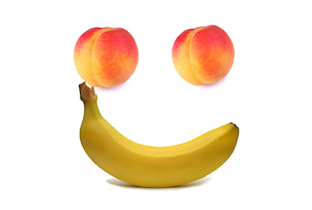

banana_61.jpg


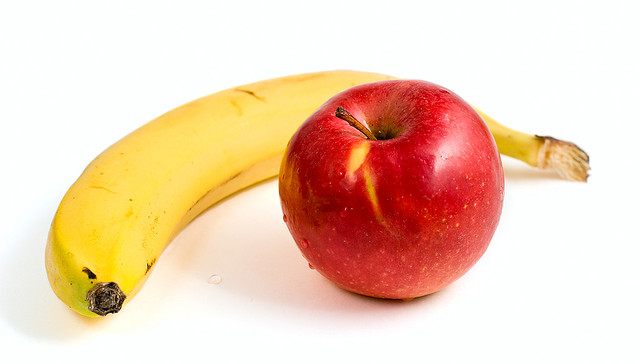

In [5]:
# ---------------------------------------------------------- #
# Execute the Function for Both Directories
# ---------------------------------------------------------- #

# Define the path directories
base_dir = Path.cwd().parents[1]
img_train_dir = base_dir / "train"
img_test_dir = base_dir / "test"

# Process Training and Validation Datasets from 'train' directory
class_train_df, img_T_widths_median, img_T_heights_median, train_logs = process_image_directory(
    directory_path = img_train_dir, 
    dataset_name = "Training and Validation Dataset"
)

# Sampling of the training and validation dataframe for verification
train_html = render_df(class_train_df, 5)

# Process Testing Datasets from 'test' directory
class_test_df, img_t_widths_median, img_t_heights_median, test_logs = process_image_directory(
    directory_path = img_test_dir, 
    dataset_name = "Testing Dataset"
)

# Sampling of the testing dataframe for verification
test_html = render_df(class_test_df, 5)

# Wrapping them html in a Flex container to enable side-by-side display
train_test_html = render_dataset_info(train_logs, train_html, test_logs, test_html)
display(HTML(train_test_html))

# Display excluded images
# Loop and display directly into the notebook output")
print(f"Excluded Image due to mislabelling caused by multiple fruits in one")
for img_name in EXCLUDED_IMAGES:
    img_path = img_train_dir / img_name
    print(f"{img_name}")
    display(IPImage(filename=img_path, width=200)) # Adjust width as needed


In [6]:
# ========================================================== #
# 5. Define a New Class: FruitLabeller and Supporting Functions
# Purpose: Create a custom PyTorch Dataset to load images, apply 
# transformations, and encode string labels to numeric indices 
# using a provided DataFrame. Includes a helper function to 
# visually summarize the dataset's class distribution.
# ========================================================== #
label_map = {
    label: idx
    for idx, label in enumerate(sorted(class_train_df["classLabel"].unique()))
}

class FruitLabeller(Dataset):
    def __init__(self, class_dataframe, img_directory, transforms = None, label_map=None):
        self.dataframe = class_dataframe
        self.directory = img_directory
        self.transforms = transforms
        
        if label_map is None:
            unique_labels = sorted(class_dataframe["classLabel"].unique())
            self.label_map = {label: idx for idx, label in enumerate(unique_labels)}
        else:
            self.label_map = label_map
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['fileName']
        img_path = self.directory / img_name
        image = Image.open(img_path).convert("RGB")

        label_str = self.dataframe.iloc[idx]['classLabel']
        label = self.label_map[label_str]

        if self.transforms:
            image = self.transforms(image)
        
        return image, label
    
def render_dataset_shape(df):
    shape_df = df['classLabel'].value_counts().sort_index().reset_index()
    shape_df.columns = ['Class Label', 'Total Image']
    return shape_df

In [7]:
# Helpers for data preparation
def transform(mean=None, std=None, data_augmentation=None):
    
    transforms_list = [ transforms.Resize((224, 224)) ]

    if data_augmentation is not None:
        transforms_list.extend(data_augmentation)
        
    transforms_list.append(transforms.ToTensor())
    
    if mean is not None and std is not None:
        transforms_list.append(
            transforms.Normalize(
                mean = mean.tolist(),
                std = std.tolist()
            )
        )
        
    return transforms.Compose(transforms_list)

In [8]:
# ========================================================== #
# 6. Data preparation
# ========================================================== #

# Split Data (80% Train, 20% Val)
train_df, val_df = train_test_split(
    class_train_df,
    test_size=0.2,
    random_state=42,
    stratify=class_train_df['classLabel']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Temporary / display transforms
temp_transforms = transform()
temp_dataset = FruitLabeller(train_df, img_train_dir, temp_transforms, label_map)
temp_loader = make_dataloader(temp_dataset, batch_size=len(temp_dataset), shuffle=False)

# Normalise pixel values for better accuracy
temp_images, temp_labels = next(iter(temp_loader))
mean, std = temp_images.mean(dim=(0,2,3)), temp_images.std(dim=(0,2,3))
print(f"Mean: {mean}\nStd: {std}")

# Actual transforms
actual_transforms = transform(mean, std)

# Instantiate PyTorch Datasets
train_dataset = FruitLabeller(train_df, img_train_dir, actual_transforms, label_map)
val_dataset = FruitLabeller(val_df, img_train_dir, actual_transforms, label_map)
test_dataset = FruitLabeller(class_test_df, img_test_dir, actual_transforms, label_map)

# Create PyTorch DataLoaders
train_loader = make_dataloader(train_dataset, batch_size=16, shuffle=True)
val_loader = make_dataloader(val_dataset, batch_size=16, shuffle=False)
test_loader = make_dataloader(test_dataset, batch_size=16, shuffle=False)

# Display Dataset Shapes
train_shape_html = render_df(render_dataset_shape(train_df), 0)
val_shape_html = render_df(render_dataset_shape(val_df), 0)
class_test_shape_html = render_df(render_dataset_shape(class_test_df), 0)

# Wrapping them html in a Flex container to enable side-by-side display
# Because sample classes are already balanced, no resampling was performed
dataset_shapes_html = render_dataset_shapes(train_shape_html, val_shape_html, class_test_shape_html)
display(HTML(dataset_shapes_html))

c:\Users\ameli\Documents\GDipSA\CAs\ML_CA\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Mean: tensor([0.8105, 0.6848, 0.5310])
Std: tensor([0.2753, 0.3213, 0.4042])


,Class Label,Total Image
0,apple,60
1,banana,57
2,orange,57
,Class Label,Total Image
0,apple,15
1,banana,14
2,orange,15
,Class Label,Total Image
0,apple,19
1,banana,18


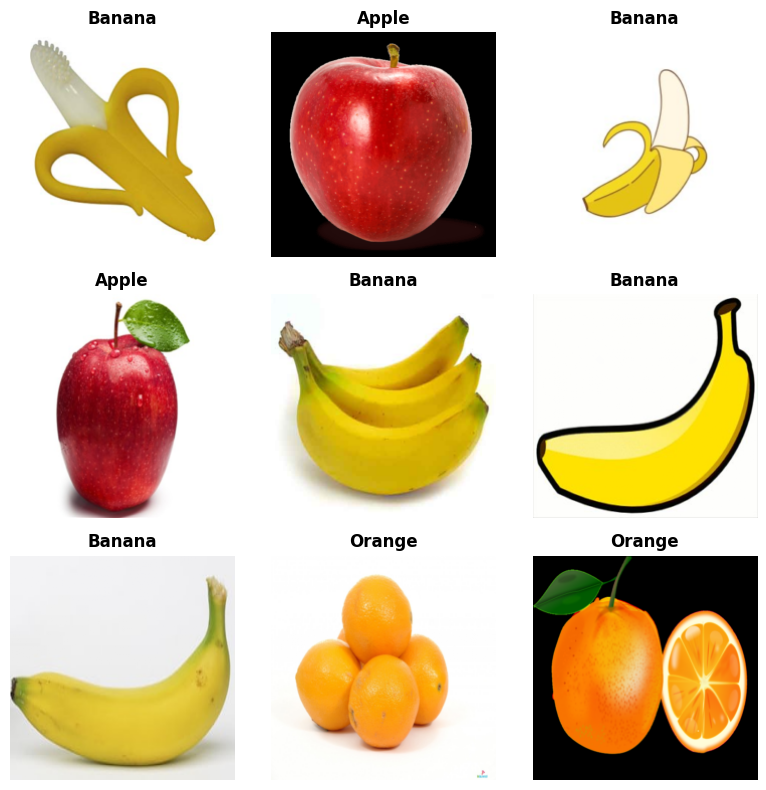

In [9]:
# Display Sample Images (Unnormalised)
class_names = {v: k for k, v in label_map.items()}

# Set up a MatPlotLib Grid
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img = np.transpose(temp_images[i].numpy(), (1, 2, 0))
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    
    # Look up the Integer Label in the Dictionary and Set it as the Title
    label_idx = temp_labels[i].item()
    ax.set_title(class_names[label_idx].capitalize(), fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Helper functions for experimentation with models
1. Building model
2. Compiling model
3. Training model
4. Evaluating model and rendering results

In [10]:
# ========================================================== #
# 7. Build and Compile CNN Architecture (224 x 224 x 3)
# Model is coded to be configurable for experimentation
# By default no dropout or augmentation
# ========================================================== #
def build_model(dropout_rate = 0.0):
    model_layers = []

    model_layers.append(Input(shape=(3, 224, 224)))
    
    # Default settings
    model_layers.extend([    
        # Conv1: 32 filters, Output shape: 224 x 224 x 32
        # Scans the raw image using a kernel to detect basic, low-level spatial features
        Conv2D(
            filters=32,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            data_format="channels_first" # PyTorch default
        ),
    
        # MaxPool: 224 x 224 -> 112 x 112
        # Downsamples feature maps with the maximum value from a 2 x 2 window
        # Reduces computational cost, controls overfitting, and makes the network 
        # robust to small shifts or translations in the image.
        MaxPooling2D(pool_size=(2, 2), data_format="channels_first"),
    
        # Conv2: 64 filters, output shape: 112 x 112 x 64
        # Scans pooled feature maps again with an increased num of filters (64) to learn 
        # higher-level, more complex and abstract features
        Conv2D(
            filters=64,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            data_format="channels_first"
        ),
    
        # MaxPool: 112 x 112 -> 56 x 56
        MaxPooling2D(pool_size=(2, 2), data_format="channels_first"),
        
        
        # Conv3: 128 filters, output shape: 56 x 56 x 128
        # Scans pooled feature maps again with an increased num of filters (128) to learn 
        # higher-level, more complex and abstract features
        Conv2D(
            filters=128,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            data_format="channels_first"
        ),
    
        # MaxPool: 56 x 56 -> 28 x 28
        MaxPooling2D(pool_size=(2, 2), data_format="channels_first"),
        
        # Flatten: 28 x 28 x 128 = 100,352
        # Flattens conv layers (3D tensors) into a 1D vector as required by Dense layers
        Flatten(),
    
        # Fully connected layer
        # learns correlations between combined features and specific fruit classes
        Dense(128, activation="relu"),
        
        # Dropout layer
        Dropout(dropout_rate),

        # Output Layer: 3 nodes (Apples, Bananas, Oranges)
        # PURPOSE: Produces the final prediction. 
        # - activation ('softmax'): Converts the raw output scores into a probability 
        # distribution, where all outputs sum up to 1. The highest probability is the prediction.
        Dense(3, activation='softmax')
    ])

    return Sequential(model_layers)

In [11]:
# ========================================================== #
# 8. Compile model
# Optimizer: Adam - Update weights while learning
# Loss: Sparse categorical crossentropy - Numerical labels
# Metrics: Accuracy - Measure correct / total preds
# ========================================================== #
def compile_model(model, learning_rate = 0.001):
    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

In [12]:
# ========================================================== #
# 9. Train CNN Model
# Epochs at 20 to allow liberal and fair experimentation
# Track processing time for experiment comparison
# ========================================================== #

# To store training/inference times for experiment comparison
if 'processing_times' not in globals() or not isinstance(processing_times, dict):
    processing_times = {}

def train_model(model_type, model, epoch=20, loader=train_loader):
    start = time.perf_counter()
    
    class GarbageCollectorCallback(keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            gc.collect()

    #Early stopping to prevent overfitting as we further experiment
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        loader,
        validation_data = val_loader,
        epochs = epoch,
        callbacks = [GarbageCollectorCallback(), early_stopping]
    )

    end = time.perf_counter()
    training_time = end - start

    processing_times[(model_type.lower() + '_training_time')] = training_time # Store time in dict

    return history


In [13]:
# ========================================================== #
# Helper: Evaluate model and render results
# ========================================================== #

# Get predictions for model
# Track processing time for experiment comparison
def get_predictions(model_type, model):

    start = time.perf_counter()
    
    # Initialize lists to store true and predicted labels for the entire dataset
    y_true = []
    y_pred = []
    
    # Iterate through the entire test_loader
    for test_images, test_labels in test_loader:
        # Get predictions for the current batch (verbose=0 suppresses per-batch output)
        batch_preds_prob = model.predict(test_images, verbose=0)
        batch_preds = np.argmax(batch_preds_prob, axis=1)
        
        # Append the results to the tracking lists
        y_true.extend(test_labels.numpy())
        y_pred.extend(batch_preds)

    end = time.perf_counter()
    inference_time = end - start
    processing_times[(model_type.lower() + '_inference_time')] = inference_time # Store time in dict

    return y_true, y_pred

# Set target names
target_names = [
    name for name in label_map.keys()
]

# Evaluation result builder
def build_result(model_name, history, y_true, y_pred, model_key=None):
    model_key_aliases = {
        'Baseline Model': 'baseline',
        'Learning Rate 0.01 Model': 'lr_01',
        'Learning Rate 0.0001 Model': 'lr_0001',
        'Dropout Model 0.7': 'dropout_07',
        'Dropout Model 0.5': 'dropout_05',
        'Dropout Model 0.3': 'dropout_03',
        'Data Augmentation Model (Geometric Modifications + 0.5)': 'augmentation_exp3a',
        'Data Augmentation Model (Geometric Modifications + 0.5 + Blur)': 'augmentation_exp3b',
        'Data Augmentation Model (Photometric Modifications + 0.5)': 'augmentation_exp3c',
        'Transfer Learning Model (MobileNetV2 + 0.5)': 'transferlearning_exp4',
        'Fine-Tuned MobileNetV2 Model': 'transferlearning_finetuned',
    }

    resolved_model_key = model_key or model_key_aliases.get(model_name, model_name.lower().replace(' ', '_'))
    report = classification_report(
        y_true, 
        y_pred,
        target_names = target_names,
        output_dict = True,
        zero_division = 0
    )

    processing_time = {
        'training': processing_times.get(f'{resolved_model_key}_training_time', 0.0),
        'inference': processing_times.get(f'{resolved_model_key}_inference_time', 0.0),
    }

    return {
        'name': model_name,
        'key': resolved_model_key,
        'history': history,

        # For experiment comparison
        'accuracy': report['accuracy'],
        'precision': report['macro avg']['precision'],
        'recall': report['macro avg']['recall'],
        'f1': report['macro avg']['f1-score'],

        # For individual reporting
        'classification_report': pd.DataFrame(report)
            .transpose()
            .round(3),
        'confusion_matrix': confusion_matrix(y_true, y_pred),
        'processing_time': processing_time,
    }

# Generate and render accuracy and loss graphs
def render_accuracy_loss_report(model_name, history, test_loss, test_accuracy, epoc_max = 21):
    
    # Extract Key Metrics from the History object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)
    
    sns.set_theme(style='darkgrid')
    plt.figure(figsize=(12, 5))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', color='blue')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', color='darkorange')
    plt.title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs', fontsize=10, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=10, fontweight='bold')
    plt.legend(loc='lower right')
    plt.xlim(0,epoc_max)
    plt.ylim(0,1.1)
    plt.grid(True)
    
    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o', color='blue')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o', color='darkorange')
    plt.title('Training and Validation Loss', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs', fontsize=10, fontweight='bold')
    plt.ylabel('Loss', fontsize=10, fontweight='bold')
    plt.legend(loc='upper right')
    plt.xlim(0,epoc_max)
    plt.grid(True)
    
    plt.tight_layout()

    # Save figure as image
    assets_dir = Path('assets')
    assets_dir.mkdir(parents=True, exist_ok=True)
    filename = assets_dir / f"{model_name.lower().replace(' ', '_')}_history.png"
    plt.savefig(filename, bbox_inches = 'tight', dpi = 150)
    plt.close()

    # Return as HTML report
    image_src = f"{filename.as_posix()}?v={int(filename.stat().st_mtime)}"
    return (
        render_section_header(
            f"Accuracy and Loss: {model_name}"
        )
        + f"""
        <p><b>Final Test Loss:</b> {test_loss:.4f}<br><b>Final Test Accuracy:</b> {test_accuracy:.4f}</p>

        <img src="{image_src}"
             width="800">
        """
    )

# Render classification report
def render_classification_report(result):
    html = render_section_header(f"Classification Report: {result['name']}")
    html += render_df(result['classification_report'], 0)
    return html

# Render confusion matrix
def render_confusion_matrix(result):
    cm = result['confusion_matrix']
    model_name = result['name']
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, 
                yticklabels=target_names)
    # plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')

    # Save figure as image
    assets_dir = Path('assets')
    assets_dir.mkdir(parents=True, exist_ok=True)
    filename = assets_dir / f"{model_name.lower().replace(' ', '_')}_cm.png"
    plt.savefig(filename, bbox_inches = 'tight', dpi = 150)
    plt.close()

    # Return as HTML report
    image_src = f"{filename.as_posix()}?v={int(filename.stat().st_mtime)}"
    return (
        render_section_header(
            f"Confusion Matrix: {model_name}"
        )
        + f"""
        <img src="{image_src}"
             width="800">
        """
    )

# Render Processing time
def render_processing_time(result, training_time=None, inference_time=None):
    model_name = result['name']

    if training_time is None or inference_time is None:
        processing_time = result.get('processing_time', {})
        training_time = processing_time.get('training', 0.0)
        inference_time = processing_time.get('inference', 0.0)

    return (
        render_section_header(
            f"Processing Time: {model_name}"
        )
        + f"""
            <p><b>Training Time:</b> {training_time:.4f}s<br><b>Inference Time:</b> {inference_time:.4f}s</p>
        """
    )

# Display all evaluation results
def display_evaluation_results(accuracy_loss_report, class_report, confusion_matrix, processing_time):
    display(HTML(accuracy_loss_report))
    display(HTML(class_report))
    display(HTML(confusion_matrix))
    display(HTML(processing_time))

## Baseline Model
1. Build CNN architecture
2. Compile model
3. Train model
4. Evaluate model

In [14]:
# ========================================================== #
# 10. Compile and Train Baseline Model
# Default Learning Rate at 0.001, Epochs = 20
# Configured to be reused on evaluation of experiments
# ========================================================== #
# Build model
baseline_model = build_model()
compile_model(baseline_model)

# Model summary
baseline_model.summary()

baseline_history = train_model('baseline', baseline_model)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

c:\Users\ameli\Documents\GDipSA\CAs\ML_CA\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 759ms/step - accuracy: 0.5632 - loss: 2.9472 - val_accuracy: 0.7045 - val_loss: 0.6581
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 743ms/step - accuracy: 0.7701 - loss: 0.4850 - val_accuracy: 0.9091 - val_loss: 0.2405
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 727ms/step - accuracy: 0.9540 - loss: 0.1684 - val_accuracy: 0.9318 - val_loss: 0.0817
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 725ms/step - accuracy: 0.9713 - loss: 0.1004 - val_accuracy: 0.8864 - val_loss: 0.2823
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 745ms/step - accuracy: 0.9655 - loss: 0.0771 - val_accuracy: 0.9318 - val_loss: 0.1364
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 750ms/step - accuracy: 0.9425 - loss: 0.1539 - val_accuracy: 0.9318 - val_loss: 0.1832
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 747ms/step - accuracy: 0.9828 - loss: 0.0655 - val_accuracy: 0.9545 - val_loss: 0.0875
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 739ms/step - accuracy: 0.9770 - loss: 0.0675 - val_accuracy: 0.

In [15]:
# ========================================================== #
# 10. Evaluate Baseline Model
# ========================================================== #
# Get predictions for model
y_true, y_pred, = get_predictions("baseline", baseline_model)

# Build evaluation result
baseline_result = build_result(
    "Baseline Model",
    baseline_history,
    y_true,
    y_pred,
)

# Generate and render Accuracy and Loss Report
test_loss, test_accuracy = baseline_model.evaluate(test_loader, verbose = 0)
baseline_accuracy_loss_report = render_accuracy_loss_report("Baseline Model", baseline_history, test_loss, test_accuracy)

# Generate and render Classification Report from result
baseline_class_report = render_classification_report(baseline_result)

# Generate and render Confusion Matrix
baseline_confusion_matrix = render_confusion_matrix(baseline_result)

# Render processing time
baseline_processing_time = render_processing_time(baseline_result, processing_times['baseline_training_time'], processing_times['baseline_inference_time'])

# Display evaluation results
display_evaluation_results(baseline_accuracy_loss_report, baseline_class_report, baseline_confusion_matrix, baseline_processing_time)

,precision,recall,f1-score,support
apple,0.947000,0.947000,0.947000,19.000000
banana,1.000000,0.889000,0.941000,18.000000
orange,0.900000,1.000000,0.947000,18.000000
accuracy,0.945000,0.945000,0.945000,0.945000
macro avg,0.949000,0.945000,0.945000,55.000000
weighted avg,0.949000,0.945000,0.945000,55.000000


## Experiment 2: Improved Model with Hyperparameter Tuning
1. Rebuild CNN architecture
2. Compile model
3. Train model
4. Evaluate model

In [16]:
# ====================================================================== #
# 11. Compile and Train Model with Learning Rate at 0.01, Epochs = 20
# ====================================================================== #
LR_01_model = build_model()
compile_model(LR_01_model, 0.01)

# Model summary
LR_01_model.summary()

LR_01_history = train_model('LR_01', LR_01_model)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


c:\Users\ameli\Documents\GDipSA\CAs\ML_CA\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 754ms/step - accuracy: 0.2759 - loss: 10.4781 - val_accuracy: 0.3409 - val_loss: 10.6233
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 754ms/step - accuracy: 0.3448 - loss: 10.5601 - val_accuracy: 0.3409 - val_loss: 10.6233
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 750ms/step - accuracy: 0.3448 - loss: 10.5601 - val_accuracy: 0.3409 - val_loss: 10.6233
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 800ms/step - accuracy: 0.3448 - loss: 10.5601 - val_accuracy: 0.3409 - val_loss: 10.6233
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 751ms/step - accuracy: 0.3448 - loss: 10.5601 - val_accuracy: 0.3409 - val_loss: 10.6233
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 724ms/step - accuracy: 0.3448 - loss: 10.5601 - val_accuracy: 0.3409 - val_loss: 10.6233


In [17]:
# =============================================================== #
# 12. Evaluate Model with Learning Rate at 0.01, Epochs = 20
# =============================================================== #

# Get predictions for model
y_true, y_pred, = get_predictions("LR_01", LR_01_model)

# Build evaluation result
LR_01_result = build_result(
    "Learning Rate 0.01 Model",
    LR_01_history,
    y_true,
    y_pred,
)

# Generate and render Accuracy and Loss Report
LR_01_test_loss, LR_01_test_accuracy = LR_01_model.evaluate(test_loader, verbose = 0)
LR_01_accuracy_loss_report = render_accuracy_loss_report("Learning Rate 0.01 Model", LR_01_history, LR_01_test_loss, LR_01_test_accuracy)

# Generate and render Classification Report from result
LR_01_class_report = render_classification_report(LR_01_result)

# Generate and render Confusion Matrix
LR_01_confusion_matrix = render_confusion_matrix(LR_01_result)

# Render processing time
LR_01_processing_time = render_processing_time(LR_01_result, processing_times['lr_01_training_time'], processing_times['lr_01_inference_time'])

# Display evaluation results
display_evaluation_results(LR_01_accuracy_loss_report, LR_01_class_report, LR_01_confusion_matrix, LR_01_processing_time)

,precision,recall,f1-score,support
apple,0.345000,1.000000,0.514000,19.000000
banana,0.000000,0.000000,0.000000,18.000000
orange,0.000000,0.000000,0.000000,18.000000
accuracy,0.345000,0.345000,0.345000,0.345000
macro avg,0.115000,0.333000,0.171000,55.000000
weighted avg,0.119000,0.345000,0.177000,55.000000


In [18]:
# ====================================================================== #
# 11. Compile and Train Model with Learning Rate at 0.0001, Epochs = 20
# ====================================================================== #

LR_0001_model = build_model()
compile_model(LR_0001_model, 0.0001)

# Model summary
LR_0001_model.summary()

LR_0001_history = train_model('LR_0001', LR_0001_model)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


c:\Users\ameli\Documents\GDipSA\CAs\ML_CA\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 774ms/step - accuracy: 0.4483 - loss: 1.1358 - val_accuracy: 0.5682 - val_loss: 0.7827
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 736ms/step - accuracy: 0.7299 - loss: 0.6222 - val_accuracy: 0.9091 - val_loss: 0.5156
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 759ms/step - accuracy: 0.9253 - loss: 0.3545 - val_accuracy: 0.9091 - val_loss: 0.3203
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 792ms/step - accuracy: 0.9138 - loss: 0.2059 - val_accuracy: 0.9318 - val_loss: 0.2344
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 730ms/step - accuracy: 0.9598 - loss: 0.1307 - val_accuracy: 0.9091 - val_loss: 0.2447
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 728ms/step - accuracy: 0.9655 - loss: 0.1085 - val_accuracy: 0.9318 - val_loss: 0.1490
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 728ms/step - accuracy: 0.9943 - loss: 0.0586 - val_accuracy: 0.9318 - val_loss: 0.2492
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 732ms/step - accuracy: 0.9885 - loss: 0.0377 - val_accuracy: 0.9545 - val_

In [19]:
# =============================================================== #
# 12. Evaluate Model with Learning Rate at 0.0001, Epochs = 20
# =============================================================== #

# Get predictions for model
y_true, y_pred, = get_predictions("LR_0001", LR_0001_model)

# Build evaluation result
LR_0001_result = build_result(
    "Learning Rate 0.0001 Model",
    LR_0001_history,
    y_true,
    y_pred,
)

# Generate and render Accuracy and Loss Report
LR_0001_test_loss, LR_0001_test_accuracy = LR_0001_model.evaluate(test_loader, verbose = 0)
LR_0001_accuracy_loss_report = render_accuracy_loss_report("Learning Rate 0.0001 Model", LR_0001_history, LR_0001_test_loss, LR_0001_test_accuracy)

# Generate and render Classification Report from result
LR_0001_class_report = render_classification_report(LR_0001_result)

# Generate and render Confusion Matrix
LR_0001_confusion_matrix = render_confusion_matrix(LR_0001_result)

# Render processing time
LR_0001_processing_time = render_processing_time(LR_0001_result, processing_times['lr_0001_training_time'], processing_times['lr_0001_inference_time'])

# Display evaluation results
display_evaluation_results(LR_0001_accuracy_loss_report, LR_0001_class_report, LR_0001_confusion_matrix, LR_0001_processing_time)

,precision,recall,f1-score,support
apple,0.950000,1.000000,0.974000,19.000000
banana,1.000000,0.889000,0.941000,18.000000
orange,0.947000,1.000000,0.973000,18.000000
accuracy,0.964000,0.964000,0.964000,0.964000
macro avg,0.966000,0.963000,0.963000,55.000000
weighted avg,0.966000,0.964000,0.963000,55.000000


In [20]:
# ========================================================== #
# 19. Compile and Train Model with Dropout at 0.7
# ========================================================== #

dropout_07_model = build_model(0.7)
compile_model(dropout_07_model)

# Model summary
dropout_07_model.summary()

dropout_07_history = train_model('dropout_07', dropout_07_model)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


c:\Users\ameli\Documents\GDipSA\CAs\ML_CA\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 872ms/step - accuracy: 0.4655 - loss: 2.6370 - val_accuracy: 0.7045 - val_loss: 0.5321
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 738ms/step - accuracy: 0.6609 - loss: 0.6968 - val_accuracy: 0.8409 - val_loss: 0.4054
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 748ms/step - accuracy: 0.7644 - loss: 0.5457 - val_accuracy: 0.8409 - val_loss: 0.3345
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 725ms/step - accuracy: 0.8736 - loss: 0.3590 - val_accuracy: 0.9773 - val_loss: 0.0801
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 763ms/step - accuracy: 0.9253 - loss: 0.1958 - val_accuracy: 0.9773 - val_loss: 0.0445
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 732ms/step - accuracy: 0.9540 - loss: 0.1096 - val_accuracy: 0.9773 - val_loss: 0.0470
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 727ms/step - accuracy: 0.9655 - loss: 0.2409 - val_accuracy: 0.9773 - val_loss: 0.0436
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 730ms/step - accuracy: 0.9483 - loss: 0.1603 - val_accuracy: 1.0000 - val_

In [21]:
# ========================================================== #
# 20. Evaluate Model with Dropout layer at 0.7
# ========================================================== #

# Get predictions for model
y_true, y_pred, = get_predictions("dropout_07", dropout_07_model)

# Build evaluation result
dropout_07_result = build_result(
    "Dropout Model 0.7",
    dropout_07_history,
    y_true,
    y_pred,
)

# Generate and render Accuracy and Loss Report
dropout_07_test_loss, dropout_07_test_accuracy = dropout_07_model.evaluate(test_loader, verbose = 0)
dropout_07_accuracy_loss_report = render_accuracy_loss_report("Dropout Model 0.7", dropout_07_history, dropout_07_test_loss, dropout_07_test_accuracy)

# Generate and render Classification Report from result
dropout_07_class_report = render_classification_report(dropout_07_result)

# Generate and render Confusion Matrix
dropout_07_confusion_matrix = render_confusion_matrix(dropout_07_result)

# Render processing time
dropout_07_processing_time = render_processing_time(dropout_07_result, processing_times['dropout_07_training_time'], processing_times['dropout_07_inference_time'])

# Display evaluation results
display_evaluation_results(dropout_07_accuracy_loss_report, dropout_07_class_report, dropout_07_confusion_matrix, dropout_07_processing_time)

,precision,recall,f1-score,support
apple,0.950000,1.000000,0.974000,19.000000
banana,1.000000,0.889000,0.941000,18.000000
orange,0.947000,1.000000,0.973000,18.000000
accuracy,0.964000,0.964000,0.964000,0.964000
macro avg,0.966000,0.963000,0.963000,55.000000
weighted avg,0.966000,0.964000,0.963000,55.000000


In [22]:
# ========================================================== #
# 23. Compile and Train Model with Dropout at 0.5
# ========================================================== #

dropout_05_model = build_model(0.5)
compile_model(dropout_05_model)

# Model summary
dropout_05_model.summary()

dropout_05_history = train_model('dropout_05', dropout_05_model)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
 3/11 ━━━━━━━━━━━━━━━━━━━━ 5s 666ms/step - accuracy: 0.3576 - loss: 2.8759

c:\Users\ameli\Documents\GDipSA\CAs\ML_CA\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 753ms/step - accuracy: 0.4885 - loss: 2.2064 - val_accuracy: 0.8636 - val_loss: 0.4969
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 745ms/step - accuracy: 0.7989 - loss: 0.4580 - val_accuracy: 0.9773 - val_loss: 0.1692
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 733ms/step - accuracy: 0.9425 - loss: 0.1763 - val_accuracy: 0.9545 - val_loss: 0.1999
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 742ms/step - accuracy: 0.9483 - loss: 0.2397 - val_accuracy: 1.0000 - val_loss: 0.0322
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 739ms/step - accuracy: 0.9655 - loss: 0.1493 - val_accuracy: 0.9318 - val_loss: 0.0914
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 725ms/step - accuracy: 0.9425 - loss: 0.1427 - val_accuracy: 0.9318 - val_loss: 0.2398
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 775ms/step - accuracy: 0.9655 - loss: 0.1048 - val_accuracy: 0.9773 - val_loss: 0.0313
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 741ms/step - accuracy: 0.9770 - loss: 0.0543 - val_accuracy: 0.9091 - val_

In [23]:
# ========================================================== #
# 24. Evaluate Model with Dropout layer at 0.5
# ========================================================== #

# Get predictions for model
y_true, y_pred, = get_predictions("dropout_05", dropout_05_model)

# Build evaluation result
dropout_05_result = build_result(
    "Dropout Model 0.5",
    dropout_05_history,
    y_true,
    y_pred,
)

# Generate and render Accuracy and Loss Report
dropout_05_test_loss, dropout_05_test_accuracy = dropout_05_model.evaluate(test_loader, verbose = 0)
dropout_05_accuracy_loss_report = render_accuracy_loss_report("Dropout Model 0.5", dropout_05_history, dropout_05_test_loss, dropout_05_test_accuracy)

# Generate and render Classification Report from result
dropout_05_class_report = render_classification_report(dropout_05_result)

# Generate and render Confusion Matrix
dropout_05_confusion_matrix = render_confusion_matrix(dropout_05_result)

# Render processing time
dropout_05_processing_time = render_processing_time(dropout_05_result, processing_times['dropout_05_training_time'], processing_times['dropout_05_inference_time'])

# Display evaluation results
display_evaluation_results(dropout_05_accuracy_loss_report, dropout_05_class_report, dropout_05_confusion_matrix, dropout_05_processing_time)

,precision,recall,f1-score,support
apple,0.950000,1.000000,0.974000,19.000000
banana,1.000000,0.889000,0.941000,18.000000
orange,0.947000,1.000000,0.973000,18.000000
accuracy,0.964000,0.964000,0.964000,0.964000
macro avg,0.966000,0.963000,0.963000,55.000000
weighted avg,0.966000,0.964000,0.963000,55.000000


In [24]:
# ========================================================== #
# 25. Compile and Train Model with Dropout at 0.3
# ========================================================== #

dropout_03_model = build_model(0.3)
compile_model(dropout_03_model)

# Model summary
dropout_03_model.summary()

dropout_03_history = train_model('dropout_03', dropout_03_model)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


c:\Users\ameli\Documents\GDipSA\CAs\ML_CA\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 786ms/step - accuracy: 0.5402 - loss: 2.3692 - val_accuracy: 0.9091 - val_loss: 0.3271
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 754ms/step - accuracy: 0.8563 - loss: 0.3491 - val_accuracy: 0.8864 - val_loss: 0.1658
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 772ms/step - accuracy: 0.9540 - loss: 0.1412 - val_accuracy: 0.9545 - val_loss: 0.0875
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 737ms/step - accuracy: 0.9828 - loss: 0.0701 - val_accuracy: 1.0000 - val_loss: 0.0342
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 732ms/step - accuracy: 0.9828 - loss: 0.0371 - val_accuracy: 0.9545 - val_loss: 0.1517
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 738ms/step - accuracy: 0.9943 - loss: 0.0253 - val_accuracy: 0.9773 - val_loss: 0.0362
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 721ms/step - accuracy: 0.9828 - loss: 0.0724 - val_accuracy: 1.0000 - val_loss: 0.0330
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 738ms/step - accuracy: 0.9770 - loss: 0.1022 - val_accuracy: 0.9545 - val_

In [25]:

# ========================================================== #
# 26. Evaluate Model with Dropout layer at 0.3
# ========================================================== #

# Get predictions for model
y_true, y_pred, = get_predictions("dropout_03", dropout_03_model)

# Build evaluation result
dropout_03_result = build_result(
    "Dropout Model 0.3",
    dropout_03_history,
    y_true,
    y_pred,
)

# Generate and render Accuracy and Loss Report
dropout_03_test_loss, dropout_03_test_accuracy = dropout_03_model.evaluate(test_loader, verbose = 0)
dropout_03_accuracy_loss_report = render_accuracy_loss_report("Dropout Model 0.3", dropout_03_history, dropout_03_test_loss, dropout_03_test_accuracy)

# Generate and render Classification Report from result
dropout_03_class_report = render_classification_report(dropout_03_result)

# Generate and render Confusion Matrix
dropout_03_confusion_matrix = render_confusion_matrix(dropout_03_result)

# Render processing time
dropout_03_processing_time = render_processing_time(dropout_03_result, processing_times['dropout_03_training_time'], processing_times['dropout_03_inference_time'])

# Display evaluation results
display_evaluation_results(dropout_03_accuracy_loss_report, dropout_03_class_report, dropout_03_confusion_matrix, dropout_03_processing_time)

,precision,recall,f1-score,support
apple,0.950000,1.000000,0.974000,19.000000
banana,1.000000,0.889000,0.941000,18.000000
orange,0.947000,1.000000,0.973000,18.000000
accuracy,0.964000,0.964000,0.964000,0.964000
macro avg,0.966000,0.963000,0.963000,55.000000
weighted avg,0.966000,0.964000,0.963000,55.000000


## Results of Experiment 2
Notes:
1. All models have epochs = 20

### Accuracy and Loss: Baseline Model (for reference)
Final Test Loss: 0.3824  
Final Test Accuracy: 0.9273


### In Order of Experiments
Accuracy and Loss: Learning Rate 0.01 Model   
Final Test Loss: 10.5500   
Final Test Accuracy: 0.3455  

Accuracy and Loss: Learning Rate 0.001 Model   
Final Test Loss:  
Final Test Accuracy: 

Accuracy and Loss: Learning Rate 0.0001 Model  
Final Test Loss: 0.3369  
Final Test Accuracy: 0.9455. 

Accuracy and Loss: Dropout Model 0.7  
Final Test Loss: 0.1470  
Final Test Accuracy: 0.9455  

Accuracy and Loss: Dropout Model 0.5  
Final Test Loss: 0.2550  
Final Test Accuracy: 0.9636  

Accuracy and Loss: Dropout Model 0.3  
Final Test Loss: 0.2790  
Final Test Accuracy: 0.9091

### Summary
1. All models with Learning Rate adjustments made no improvement in Final Test Accuracy over the baseline model, hence I did not select any models with adjusted Learning Rate to pair with models with adjusted Dropout values.

2. The model with Dropout at 0.5 scored a final test accuracy higher than baseline model, hence it is suggested that the next few experiments utilise this particular model for further experiments.

# Investigating Consistent Misclassification of 2 images

Indices of misclassified images: [28 30]


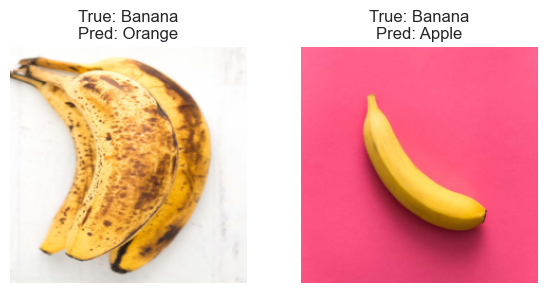

In [26]:
# Investigate misclassified images
y_true = np.array(y_true)
y_pred = np.array(y_pred)
misclass = np.where(y_pred != y_true)[0]
print(f"Indices of misclassified images: {misclass}")

if len(misclass) == 0:
    print("No misclassified images found.")
else:
    # Convert normalization stats for RGB unnormalization during plotting
    mean_np = mean.cpu().numpy().reshape(1, 1, 3)
    std_np = std.cpu().numpy().reshape(1, 1, 3)

    # Create a dynamic grid side-by-side
    fig, axes = plt.subplots(1, len(misclass), figsize=(3 * len(misclass), 3))
    if len(misclass) == 1:
        axes = [axes]

    # Show the misclassified images side by side
    for i, idx in enumerate(misclass):
        img, label = test_dataset[idx]

        # CHW -> HWC
        img_to_show = np.transpose(img.numpy(), (1, 2, 0))

        # Reverse normalization to visualize original colors
        img_to_show = (img_to_show * std_np) + mean_np
        img_to_show = np.clip(img_to_show, 0, 1)

        ax = axes[i]
        pred_label = int(y_pred[idx])
        ax.imshow(img_to_show)
        ax.set_title(f"True: {class_names[int(label)].capitalize()}\nPred: {class_names[pred_label].capitalize()}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

## Experiment 3: Data Augmentation Model
After reviewing experiment 2 results, we saw a consistency of 2 misclassified images. To observe the effects of data augmentation on these misclassified images, we have implemented data augmentation.

**Experiment 3A:** Geometric Modifications

In [27]:
# ========================================================== #
# 27. Compile and Train Model with Geometric Augmentation
# Without Gaussian blur
# ========================================================== #

# 1. Define the data augmentation pipeline for Experiment 3A
# exp3a_train_transforms = [
#     # layers.Permute((2, 3, 1)),  # CHW -> HWC

#     layers.RandomFlip("horizontal", data_format="channels_first"),
#     layers.RandomRotation(0.1, data_format="channels_first"),
#     layers.RandomZoom(height_factor=(-0.1, 0.0), data_format="channels_first"),
#     # layers.RandomGaussianBlur(
#     #     factor=(0.0, 0.02),
#     #     kernel_size=3,
#     #     sigma=(0.1, 0.3),
#     #     value_range=(0, 1),
#     #     data_format="channels_first"
#     # )

#     # layers.Permute((3, 1, 2))   # HWC -> CHW
# ]

# Using PyTorch to insert in transform
# Reason being: want to experiment with Gaussian Blur, Brightness, Contrast
exp3a_augmentation = [
    transforms.RandomHorizontalFlip(p=0.5),

    # Keras RandomRotation(0.1) ≈ 10% of 360 degrees = 36 degrees
    transforms.RandomRotation(degrees=36),

    # Keras RandomZoom(height_factor=(-0.1, 0.0))
    # Approximation: randomly crop 90% to 100% of image, then resize back to 224x224
    transforms.RandomResizedCrop(
        size=(224, 224),
        scale=(0.9, 1.0)
    )
]

# Transform with augmentation
exp3a_train_transforms = transform(mean, std, exp3a_augmentation)
exp3a_train_dataset = FruitLabeller(train_df, img_train_dir, exp3a_train_transforms, label_map)
exp3a_train_loader = make_dataloader(exp3a_train_dataset, batch_size=16, shuffle=True)

# 2. Instantiate Model
# model_experiment_3a = build_model(dropout_rate = 0.5, data_augmentation = exp3a_train_transforms)
model_experiment_3a = build_model(0.5)

# 3. Compile the model using custom helper function , LR : 0.001
compile_model(model_experiment_3a)

# 4. Print the summary
model_experiment_3a.summary()

# 5. Train using custom training helper function 
exp3a_history = train_model('augmentation_exp3a', model_experiment_3a, 20, exp3a_train_loader)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

c:\Users\ameli\Documents\GDipSA\CAs\ML_CA\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 764ms/step - accuracy: 0.4943 - loss: 4.3804 - val_accuracy: 0.6591 - val_loss: 1.0319
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 742ms/step - accuracy: 0.7011 - loss: 0.7039 - val_accuracy: 0.9773 - val_loss: 0.2631
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 745ms/step - accuracy: 0.8908 - loss: 0.2835 - val_accuracy: 1.0000 - val_loss: 0.0498
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 747ms/step - accuracy: 0.9540 - loss: 0.1747 - val_accuracy: 0.9773 - val_loss: 0.0718
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 759ms/step - accuracy: 0.9483 - loss: 0.2334 - val_accuracy: 0.9545 - val_loss: 0.1082
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 753ms/step - accuracy: 0.9655 - loss: 0.1075 - val_accuracy: 0.9773 - val_loss: 0.0617
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 752ms/step - accuracy: 0.9828 - loss: 0.1311 - val_accuracy: 0.9318 - val_loss: 0.1499
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 783ms/step - accuracy: 0.9425 - loss: 0.1378 - val_accuracy: 0.

In [28]:
# ========================================================
# 28. Evaluate Model with Geometric Augmentation + Dropout
# ========================================================

# 1. Get predictions for the new model
y_true, y_pred = get_predictions("augmentation_exp3a", model_experiment_3a)

# 2. Build the result registry profile
exp3a_result = build_result(
    "Data Augmentation Model (Geometric Modifications + 0.5)",
    exp3a_history,
    y_true,
    y_pred
)

# 3. Generate and render Accuracy and Loss Report
test_loss, test_accuracy = model_experiment_3a.evaluate(test_loader, verbose=0)
exp3a_accuracy_loss_report = render_accuracy_loss_report("Data Augmentation Model (Geometric Modifications + 0.5)", exp3a_history, test_loss, test_accuracy, 31)

# 4. Generate Classification Report and Confusion Matrix
exp3a_class_report = render_classification_report(exp3a_result)
exp3a_confusion_matrix = render_confusion_matrix(exp3a_result)

# 5. Render processing times
exp3a_processing_time = render_processing_time(
    exp3a_result,
    processing_times['augmentation_exp3a_training_time'],
    processing_times['augmentation_exp3a_inference_time']
)

# 6. Display the final evaluation dashboard
display_evaluation_results(exp3a_accuracy_loss_report, exp3a_class_report, exp3a_confusion_matrix, exp3a_processing_time)

,precision,recall,f1-score,support
apple,0.947000,0.947000,0.947000,19.000000
banana,1.000000,0.889000,0.941000,18.000000
orange,0.900000,1.000000,0.947000,18.000000
accuracy,0.945000,0.945000,0.945000,0.945000
macro avg,0.949000,0.945000,0.945000,55.000000
weighted avg,0.949000,0.945000,0.945000,55.000000


In [29]:
# ========================================================== #
# 27. Compile and Train Model with Geometric Augmentation
# With Gaussian blur
# ========================================================== #

# Using PyTorch to insert in transform
# Reason being: want to experiment with Gaussian Blur, Brightness, Contrast
exp3b_augmentation = [
    transforms.RandomHorizontalFlip(p=0.5),

    # Keras RandomRotation(0.1) ≈ 10% of 360 degrees = 36 degrees
    transforms.RandomRotation(degrees=36),

    # Keras RandomZoom(height_factor=(-0.1, 0.0))
    # Approximation: randomly crop 90% to 100% of image, then resize back to 224x224
    transforms.RandomResizedCrop(
        size=(224, 224),
        scale=(0.9, 1.0)
    ),

    # Light blur as dataset is small
    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 0.3)
    )
]

# Transform with augmentation
exp3b_train_transforms = transform(mean, std, exp3b_augmentation)
exp3b_train_dataset = FruitLabeller(train_df, img_train_dir, exp3b_train_transforms, label_map)
exp3b_train_loader = make_dataloader(exp3b_train_dataset, batch_size=16, shuffle=True)

# 2. Instantiate Model
# model_experiment_3a = build_model(dropout_rate = 0.5, data_augmentation = exp3a_train_transforms)
model_experiment_3b = build_model(0.5)

# 3. Compile the model using custom helper function , LR : 0.001
compile_model(model_experiment_3b)

# 4. Print the summary
model_experiment_3b.summary()

# 5. Train using custom training helper function 
exp3b_history = train_model('augmentation_exp3b', model_experiment_3b, 20, exp3b_train_loader)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

c:\Users\ameli\Documents\GDipSA\CAs\ML_CA\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 788ms/step - accuracy: 0.5345 - loss: 2.6153 - val_accuracy: 0.7273 - val_loss: 0.5572
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 779ms/step - accuracy: 0.8448 - loss: 0.4457 - val_accuracy: 0.9318 - val_loss: 0.1419
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 805ms/step - accuracy: 0.9483 - loss: 0.1483 - val_accuracy: 1.0000 - val_loss: 0.0611
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 769ms/step - accuracy: 0.9540 - loss: 0.1057 - val_accuracy: 0.9545 - val_loss: 0.1218
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 767ms/step - accuracy: 0.9713 - loss: 0.1299 - val_accuracy: 1.0000 - val_loss: 0.0301
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 787ms/step - accuracy: 0.9540 - loss: 0.2316 - val_accuracy: 0.9545 - val_loss: 0.1500
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 761ms/step - accuracy: 0.9655 - loss: 0.1222 - val_accuracy: 1.0000 - val_loss: 0.0432
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 768ms/step - accuracy: 0.9770 - loss: 0.0628 - val_accuracy: 1.

In [30]:
# ========================================================
# 28. Evaluate Model with Geometric Augmentation + Dropout + Blur
# ========================================================

# 1. Get predictions for the new model
y_true, y_pred = get_predictions("augmentation_exp3b", model_experiment_3b)

# 2. Build the result registry profile
exp3b_result = build_result(
    "Data Augmentation Model (Geometric Modifications + 0.5)",
    exp3b_history,
    y_true,
    y_pred
)

# 3. Generate and render Accuracy and Loss Report
test_loss, test_accuracy = model_experiment_3b.evaluate(test_loader, verbose=0)
exp3b_accuracy_loss_report = render_accuracy_loss_report("Data Augmentation Model (Geometric Modifications + 0.5 + Blur)", exp3b_history, test_loss, test_accuracy, 31)

# 4. Generate Classification Report and Confusion Matrix
exp3b_class_report = render_classification_report(exp3b_result)
exp3b_confusion_matrix = render_confusion_matrix(exp3b_result)

# 5. Render processing times
exp3b_processing_time = render_processing_time(
    exp3b_result,
    processing_times['augmentation_exp3b_training_time'],
    processing_times['augmentation_exp3b_inference_time']
)

# 6. Display the final evaluation dashboard
display_evaluation_results(exp3b_accuracy_loss_report, exp3b_class_report, exp3b_confusion_matrix, exp3b_processing_time)

,precision,recall,f1-score,support
apple,0.950000,1.000000,0.974000,19.000000
banana,1.000000,0.889000,0.941000,18.000000
orange,0.947000,1.000000,0.973000,18.000000
accuracy,0.964000,0.964000,0.964000,0.964000
macro avg,0.966000,0.963000,0.963000,55.000000
weighted avg,0.966000,0.964000,0.963000,55.000000


**Experiment 3B**: Photometric Modifications

In [31]:
# ========================================================== #
# 29. Compile and Train Model with Photometric Augmentation
# ========================================================== #

# 1. Define the data augmentation pipeline for Experiment 3B
# exp3b_train_transforms = [
#     # layers.Permute((2, 3, 1)),
#     layers.RandomBrightness(factor=0.05, data_format="channels_first"),
#     layers.RandomContrast(factor=0.05, data_format="channels_first"),
#     layers.ReLU(max_value=1.0),            
#     # layers.Permute((3, 1, 2))
# ]

# Use PyTorch
exp3c_augmentation = [
    transforms.ColorJitter(
        brightness=0.05,
        contrast=0.05
    )     
]

# Transform with augmentation
exp3c_train_transforms = transform(mean, std, exp3c_augmentation)
exp3c_train_dataset = FruitLabeller(train_df, img_train_dir, exp3c_train_transforms, label_map)
exp3c_train_loader = make_dataloader(exp3c_train_dataset, batch_size=16, shuffle=True)

# 2. Instantiate the Experiment 3b Model using the original build_model structure
model_experiment_3c = build_model(0.5)

# 3. Compile the model using custom helper function
# Sticking to the best learning rate used in Exp 2 (0.0005)
compile_model(model_experiment_3c)

# 4. Print the summary to verify the augmentation layers are included at the top
model_experiment_3c.summary()

# 5. Train using custom training helper function
exp3c_history = train_model('augmentation_exp3c', model_experiment_3c, 20, exp3c_train_loader)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

c:\Users\ameli\Documents\GDipSA\CAs\ML_CA\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 754ms/step - accuracy: 0.5805 - loss: 1.3166 - val_accuracy: 0.8182 - val_loss: 0.4728
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 761ms/step - accuracy: 0.8276 - loss: 0.5002 - val_accuracy: 0.9545 - val_loss: 0.1596
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 804ms/step - accuracy: 0.9080 - loss: 0.2736 - val_accuracy: 0.9318 - val_loss: 0.2135
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 755ms/step - accuracy: 0.9425 - loss: 0.1894 - val_accuracy: 0.9318 - val_loss: 0.2014
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 745ms/step - accuracy: 0.9598 - loss: 0.1335 - val_accuracy: 0.9773 - val_loss: 0.0346
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 741ms/step - accuracy: 0.9885 - loss: 0.0849 - val_accuracy: 0.9773 - val_loss: 0.0502
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 747ms/step - accuracy: 0.9138 - loss: 0.2843 - val_accuracy: 0.9773 - val_loss: 0.0304
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 738ms/step - accuracy: 0.9770 - loss: 0.1293 - val_accuracy: 0.

In [32]:
# ========================================================
# 30. Evaluate Model with Photometric Augmentation + Dropout
# ========================================================

# 1. Get predictions for the new model
y_true, y_pred = get_predictions("augmentation_exp3c", model_experiment_3c)

# 2. Build the result registry profile
exp3c_result = build_result(
    "Data Augmentation Model (Photometric Modifications + 0.5)",
    exp3c_history,
    y_true,
    y_pred
)

# 3. Generate and render Accuracy and Loss Report
test_loss, test_accuracy = model_experiment_3c.evaluate(test_loader, verbose=0)
exp3c_accuracy_loss_report = render_accuracy_loss_report("Data Augmentation Model (Photometric Modifications + 0.5)", exp3c_history, test_loss, test_accuracy, 31)

# 4. Generate Classification Report and Confusion Matrix
exp3c_class_report = render_classification_report(exp3c_result)
exp3c_confusion_matrix = render_confusion_matrix(exp3c_result)

# 5. Render processing times
exp3c_processing_time = render_processing_time(
    exp3c_result,
    processing_times['augmentation_exp3c_training_time'],
    processing_times['augmentation_exp3c_inference_time']
)

# 6. Display the final evaluation dashboard
display_evaluation_results(exp3c_accuracy_loss_report, exp3c_class_report, exp3c_confusion_matrix, exp3c_processing_time)

,precision,recall,f1-score,support
apple,0.950000,1.000000,0.974000,19.000000
banana,1.000000,0.889000,0.941000,18.000000
orange,0.947000,1.000000,0.973000,18.000000
accuracy,0.964000,0.964000,0.964000,0.964000
macro avg,0.966000,0.963000,0.963000,55.000000
weighted avg,0.966000,0.964000,0.963000,55.000000


## Experiment 4: Transfer Learning Model
1. Rebuild CNN architecture
2. Compile model
3. Train model
4. Evaluate model

In [33]:
# ========================================================== #
# 31. Compile and Train Model using Transfer Learning
# ========================================================== #

# 1. Instantiate Pre-trained MobileNetV2 model without its classification head.
keras.config.set_image_data_format('channels_first')
model_pretrained = keras.applications.MobileNetV2(
    input_shape=(3, 224, 224),
    include_top=False,
    weights='imagenet'
)

# 2. Freeze the pre-trained model so its pre-learned feature maps are not destroyed
model_pretrained.trainable = False

# 3. Build the custom classification model incorporating the 
model_experiment_4 = Sequential([
    Input(shape=(3, 224, 224)),
    
    # Preprocessing: MobileNetV2 expects pixel values between [-1, 1].
    Rescaling(scale=2.0, offset=-1.0),
    
    # Pass the scaled images through the frozen MobileNetV2 base
    model_pretrained,
    
    # Compress the spatial dimensions while retaining feature depth.
    GlobalAveragePooling2D(data_format="channels_first"),
    
    # Add your custom dense layers for the 3 fruit classes
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

# 4. Compile the model using custom helper function, LR : 0.001
compile_model(model_experiment_4)

# 5. Print the summary
model_experiment_4.summary()

# 6. Train using custom training helper function 
exp4_history = train_model('transferLearning_exp4', model_experiment_4)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280, 7, 7)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
 2/11 ━━━━━━━━━━━━━━━━━━━━ 7s 789ms/step - accuracy: 0.2812 - loss: 1.8127

c:\Users\ameli\Documents\GDipSA\CAs\ML_CA\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 888ms/step - accuracy: 0.6494 - loss: 0.8838 - val_accuracy: 0.9545 - val_loss: 0.2202
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 864ms/step - accuracy: 0.9023 - loss: 0.2478 - val_accuracy: 0.9545 - val_loss: 0.1234
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 819ms/step - accuracy: 0.9540 - loss: 0.1791 - val_accuracy: 0.9773 - val_loss: 0.0994
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 803ms/step - accuracy: 0.9713 - loss: 0.0793 - val_accuracy: 0.9773 - val_loss: 0.0802
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 809ms/step - accuracy: 0.9943 - loss: 0.0525 - val_accuracy: 0.9545 - val_loss: 0.0999
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 800ms/step - accuracy: 1.0000 - loss: 0.0366 - val_accuracy: 0.9773 - val_loss: 0.0868
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 795ms/step - accuracy: 0.9943 - loss: 0.0313 - val_accuracy: 0.9773 - val_loss: 0.0904
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 805ms/step - accuracy: 0.9828 - loss: 0.0561 - val_accuracy: 0.9773 - val

In [34]:
# ========================================================
# 32. Evaluate Model with Transfer Learning + Dropout
# ========================================================

# 1. Get predictions for the new model
y_true, y_pred = get_predictions("transferlearning_exp4", model_experiment_4)

# 2. Build the result registry profile
exp4_result = build_result(
    "Transfer Learning Model (MobileNetV2 + 0.5)",
    exp4_history,
    y_true,
    y_pred
)

# 3. Generate and render Accuracy and Loss Report
test_loss, test_accuracy = model_experiment_4.evaluate(test_loader, verbose=0)
exp4_accuracy_loss_report = render_accuracy_loss_report("Tranfer Learning Model (MobileNetV2 + 0.5)", exp4_history, test_loss, test_accuracy, 21)

# 4. Generate Classification Report and Confusion Matrix
exp4_class_report = render_classification_report(exp4_result)
exp4_confusion_matrix = render_confusion_matrix(exp4_result)

# 5. Render processing times
exp4_processing_time = render_processing_time(
    exp4_result,
    processing_times['transferlearning_exp4_training_time'],
    processing_times['transferlearning_exp4_inference_time']
)

# 6. Display the final evaluation dashboard
display_evaluation_results(exp4_accuracy_loss_report, exp4_class_report, exp4_confusion_matrix, exp4_processing_time)

,precision,recall,f1-score,support
apple,1.000000,0.895000,0.944000,19.000000
banana,1.000000,1.000000,1.000000,18.000000
orange,0.900000,1.000000,0.947000,18.000000
accuracy,0.964000,0.964000,0.964000,0.964000
macro avg,0.967000,0.965000,0.964000,55.000000
weighted avg,0.967000,0.964000,0.964000,55.000000


In [35]:
# ========================================================== #
# 33s. Fine-Tune the Transfer Learning Model
# ========================================================== #

# 1. Unfreeze the base MobileNetV2 model
model_pretrained.trainable = True

# 2. Freeze all layers except the top 20 layers
for layer in model_pretrained.layers[:-20]:
    layer.trainable = False

# 3. Recompile the model with a much lower learning rate
compile_model(model_experiment_4, learning_rate = 1e-5)

# 4. Continue training for 10 more epochs
fine_tune_history = train_model('transferLearning_finetuned', model_experiment_4, 10)

Epoch 1/10
 2/11 ━━━━━━━━━━━━━━━━━━━━ 6s 703ms/step - accuracy: 0.5938 - loss: 0.9759

c:\Users\ameli\Documents\GDipSA\CAs\ML_CA\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 908ms/step - accuracy: 0.7184 - loss: 0.7424 - val_accuracy: 0.9773 - val_loss: 0.0811
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 966ms/step - accuracy: 0.7989 - loss: 0.5680 - val_accuracy: 0.9773 - val_loss: 0.0828
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 900ms/step - accuracy: 0.8333 - loss: 0.3862 - val_accuracy: 0.9773 - val_loss: 0.0838
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 881ms/step - accuracy: 0.8391 - loss: 0.3326 - val_accuracy: 0.9773 - val_loss: 0.0857
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 897ms/step - accuracy: 0.8966 - loss: 0.3190 - val_accuracy: 0.9773 - val_loss: 0.0893
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 852ms/step - accuracy: 0.9138 - loss: 0.2270 - val_accuracy: 0.9773 - val_loss: 0.0917


In [36]:
# ========================================================
# 35. Evaluate the Fine-Tuned Model
# ========================================================

# 1. Get predictions for the new model
y_true, y_pred = get_predictions("transferlearning_finetuned", model_experiment_4)

# 2. Build the result registry profile
finetuned_result = build_result(
    "Fine-Tuned MobileNetV2 Model",
    fine_tune_history,
    y_true,
    y_pred
)

# 3. Generate and render Accuracy and Loss Report
test_loss, test_accuracy = model_experiment_4.evaluate(test_loader, verbose=0)
finetuned_accuracy_loss_report = render_accuracy_loss_report("Fine-Tuned MobileNetV2 Model", fine_tune_history, test_loss, test_accuracy, 11)

# 4. Generate Classification Report and Confusion Matrix
finetuned_class_report = render_classification_report(finetuned_result)
finetuned_confusion_matrix = render_confusion_matrix(finetuned_result)

# 5. Render processing times
finetuned_processing_time = render_processing_time(
    finetuned_result, 
    processing_times['transferlearning_finetuned_training_time'], 
    processing_times['transferlearning_finetuned_inference_time']
)

# 6. Display the final evaluation dashboard
display_evaluation_results(finetuned_accuracy_loss_report, finetuned_class_report, finetuned_confusion_matrix, finetuned_processing_time)

,precision,recall,f1-score,support
apple,1.000000,0.895000,0.944000,19.000000
banana,1.000000,1.000000,1.000000,18.000000
orange,0.900000,1.000000,0.947000,18.000000
accuracy,0.964000,0.964000,0.964000,0.964000
macro avg,0.967000,0.965000,0.964000,55.000000
weighted avg,0.967000,0.964000,0.964000,55.000000


## Summary of Findings
1. Misclassified Images
2. Test Accuracy across Experiments
3. Model Efficiency across Experiments

Summary of Findings

1 Overall Findings from the CA

A. Finding

The experiments demonstrated that fruit classification performance was influenced by multiple factors, including learning rate selection, regularisation strategy, data augmentation, and model architecture. While all CNN-based models achieved relatively strong results, the impact of each optimisation technique varied considerably across the experiments.

B. Evidence

The baseline CNN achieved a test accuracy of 94.55%, confirming that the proposed architecture was capable of learning meaningful visual features from the fruit dataset. Performance improved to 96.36% following learning rate optimisation and reached 98.18% with the Dropout 0.5 configuration. Geometric augmentation maintained strong classification performance, whereas photometric augmentation reduced accuracy to 85.45%. In addition, the MobileNetV2 transfer learning model achieved 96.36%, demonstrating competitive performance but not surpassing the strongest custom CNN configuration.

C. Analysis

Several important observations emerged from the experimental results. First, improvements in performance were not directly associated with increased model complexity. Although transfer learning provided stable and reliable results, a carefully optimised CNN achieved superior performance on this dataset. Second, optimisation strategies such as learning rate tuning and dropout regularisation contributed more to performance improvement than architectural changes. Finally, the augmentation experiments highlighted that the effectiveness of data augmentation depends on the type of transformation applied. Transformations that preserved the essential visual characteristics of the fruit images were beneficial, whereas more aggressive modifications could negatively affect classification performance.


2 Misclassified Images

A. Finding

Classification errors were extremely limited and concentrated within a very small number of challenging samples.

B. Evidence

The best-performing Dropout 0.5 model achieved a test accuracy of 98.18%, correctly classifying 54 out of 55 test images. Only one image was misclassified. The transfer learning model achieved 96.36% accuracy and misclassified two images, both involving confusion between Apple and Orange categories.

C. Analysis

The low number of errors indicates that the model successfully learned highly discriminative visual features for all three fruit categories. Another notable observation was that the remaining errors were not randomly distributed. Instead, they occurred between visually similar classes, suggesting that some overlap existed within the learned feature representations of Apple and Orange images.

Banana images were consistently classified with high accuracy across experiments, indicating that their visual characteristics were easier for the model to distinguish.

D. Implication

Future improvements should focus on analysing difficult class boundaries and ambiguous samples rather than redesigning the overall architecture.

E. Conclusion

The misclassification analysis confirms that the final model achieved strong class separation and reliable predictive performance, with only a small number of class-specific errors remaining.



3 Test Accuracy Across Experiments

A. Finding

Model performance improved progressively through appropriate hyperparameter tuning and regularisation, although not every modification resulted in positive outcomes.

B. Evidence

Compared with the baseline accuracy of 94.55%, reducing the learning rate to 0.0005 improved performance to 96.36%. However, further reductions to 0.00001 and 0.000005 lowered accuracy to 90.91% and 92.73%, respectively.

Among the dropout experiments, the 0.5 configuration achieved the highest accuracy of 98.18%, while both the 0.3 and 0.7 configurations achieved 96.36%.

Data augmentation produced mixed results. Geometric augmentation maintained strong performance at 96.36%, whereas photometric augmentation reduced accuracy significantly to 85.45%. Transfer learning achieved 96.36%.

C. Analysis

Several important observations emerged from these experiments. First, moderate adjustments to the learning rate improved optimisation performance, but excessively small learning rates prevented the model from learning efficiently within the available training epochs.

Second, dropout regularisation proved highly effective. The superior performance of the 0.5 configuration suggests that moderate regularisation reduced overfitting while preserving useful feature information. In contrast, both weaker and stronger dropout settings were less effective.

Finally, the augmentation experiments demonstrated that not all transformations are equally beneficial. Geometric transformations preserved essential visual characteristics of the fruit images, whereas aggressive colour and brightness modifications appeared to distort features that were important for classification.

D. Implication

The results emphasise that model performance depends on finding an appropriate balance between training parameters, regularisation strength, and data preprocessing strategies.

E. Conclusion

Among all experiments, the Dropout 0.5 configuration produced the strongest classification performance and emerged as the best-performing model in the project.



 4. Model Efficiency Across Experiments

A. Finding

The most accurate model was also one of the most efficient models evaluated throughout the project.

B. Evidence

The Dropout 0.5 model achieved the highest test accuracy while maintaining reasonable training and inference times. In contrast, experiments using extremely small learning rates required substantially longer training times despite producing lower accuracy. Transfer learning reduced training effort but resulted in slower inference performance than the custom CNN models.

C. Analysis

The efficiency results reveal that higher computational complexity does not necessarily lead to better classification performance. Although transfer learning introduced a more advanced architecture, it did not outperform the best custom CNN. Similarly, reducing the learning rate significantly increased training time without producing corresponding improvements in accuracy.

These observations suggest that efficiency should be evaluated alongside predictive performance when selecting a final model.

D. Implication

For practical deployment scenarios, model selection should consider not only classification accuracy but also computational requirements and inference speed.

E. Conclusion

The Dropout 0.5 model achieved the most favourable balance between predictive performance, training efficiency, and deployment practicality.



5. Overall Conclusion

The project successfully achieved its objective of developing an effective fruit image classification model. Through systematic experimentation, the effects of learning rate tuning, regularisation, data augmentation, and transfer learning were evaluated and compared.

Among all evaluated approaches, the Dropout 0.5 CNN model delivered the strongest overall performance, achieving the highest test accuracy of 98.18% while maintaining efficient computational performance and strong generalisation capability.

Overall, the findings demonstrate that careful model optimisation contributed more to performance improvement than increased architectural complexity. Based on the experimental results, the Dropout 0.5 CNN model is recommended as the final model for this project.


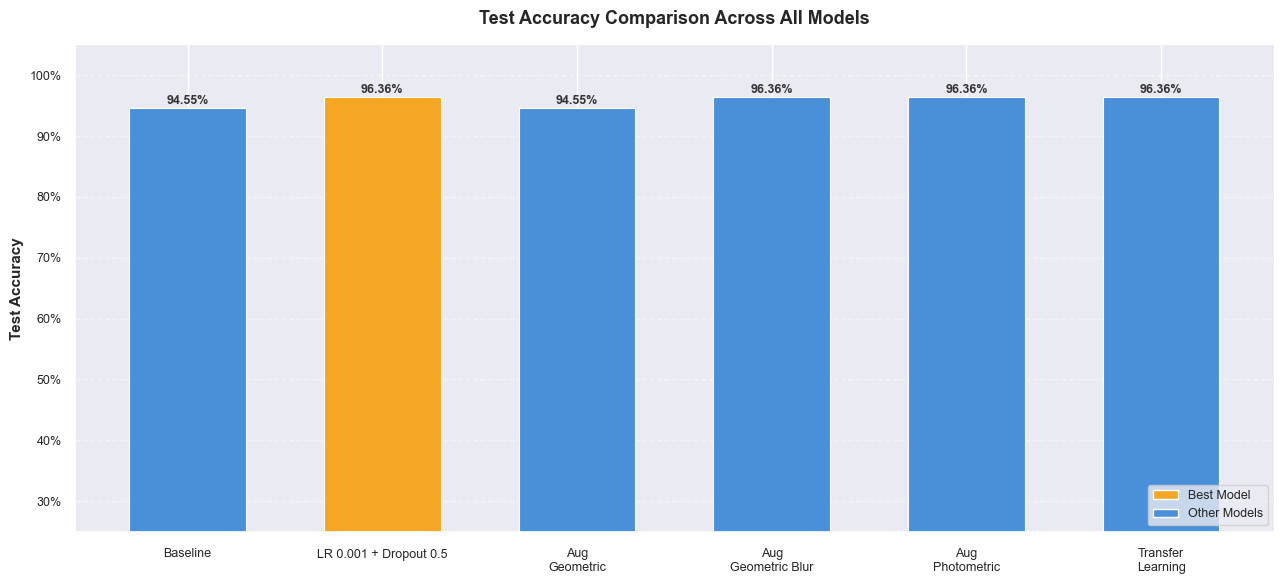

In [37]:
# ========================================================== #
# 33. Test Accuracy Comparison Bar Chart Across All Models
# Purpose: Visualise and compare the final test accuracy of
# every model trained in this notebook using a bar chart.
# ========================================================== #

# Collect all model results into a single list
all_results = [
    baseline_result,
    dropout_05_result,
    exp3a_result,
    exp3b_result,
    exp3c_result,
    exp4_result,
    # finetuned_result
]

# Short display names for the x-axis
short_names = [
    "Baseline",
    "LR 0.001 + Dropout 0.5",
    "Aug\nGeometric",
    "Aug\nGeometric Blur",
    "Aug\nPhotometric",
    "Transfer\nLearning",
    # "Fine-Tuned\nTransfer Learning"
]

# Extract test accuracies
test_accuracies = [r['accuracy'] for r in all_results]

# Identify the best model
best_idx = test_accuracies.index(max(test_accuracies))

# Assign bar colours
bar_colours = ['#f5a623' if i == best_idx else '#4a90d9' for i in range(len(short_names))]

fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(short_names, test_accuracies, color=bar_colours, edgecolor='white', linewidth=0.8, width=0.6)

# Annotate each bar with its accuracy value
for bar, acc in zip(bars, test_accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{acc:.2%}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#333333'
    )

# Formatting
ax.set_ylim(0.25, 1.05)
ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Test Accuracy Comparison Across All Models', fontsize=13, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.tick_params(axis='x', labelsize=9, pad=6)
ax.tick_params(axis='y', labelsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#f5a623', label='Best Model'),
    Patch(facecolor='#4a90d9', label='Other Models'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

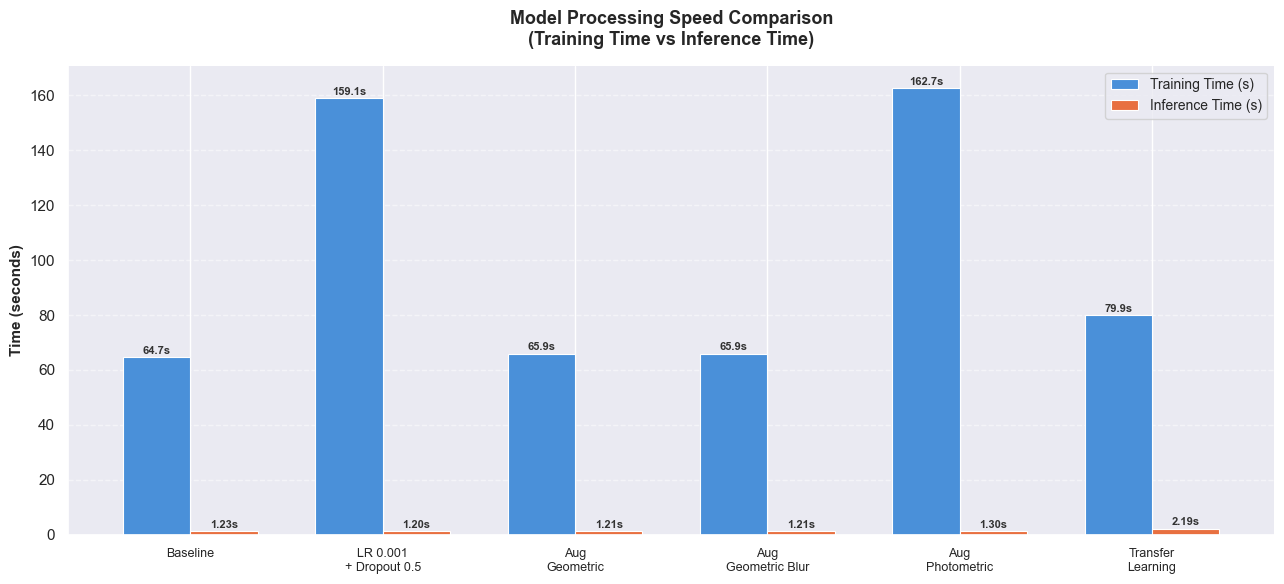

Model                           Training Time (s)   Inference Time (s)
Baseline                                  64.73s ◄ fastest             1.2265s
LR 0.001 + Dropout 0.5                   159.09s                       1.1966s ◄ fastest
Aug Geometric (Exp3a)                     65.87s                       1.2105s
Aug Photometric (Exp3b)                   65.87s                       1.2105s
Aug Photometric (Exp3c)                  162.74s                       1.2983s
Transfer Learning (Exp4)                  79.85s                       2.1914s

Fastest training : Baseline (64.73s)
Fastest inference: LR 0.001 + Dropout 0.5 (1.1966s)


In [38]:
# ========================================================== #
# 34. Summary Sheet: Model Efficiency Comparison
#     Processing Speed — Training Time vs Inference Time
#     across all models from Section 33
# ========================================================== #

import matplotlib.pyplot as plt
import numpy as np

# Gather the finalized results so timing is read from each result object
result_set = [
    baseline_result,
    dropout_05_result,
    exp3a_result,
    exp3b_result,
    exp3c_result,
    exp4_result,
    # finetuned_result
]

# ----------------------------------------------------------
# Model labels (same order as Section 33 bar chart)
# ----------------------------------------------------------
model_labels = [
    "Baseline",
    "LR 0.001\n+ Dropout 0.5",
    "Aug\nGeometric",
    "Aug\nGeometric Blur",
    "Aug\nPhotometric",
    "Transfer\nLearning",
]

training_times = [result['processing_time']['training'] for result in result_set]
inference_times = [result['processing_time']['inference'] for result in result_set]

# ----------------------------------------------------------
# ① Grouped Bar Chart — Training vs Inference Time
# ----------------------------------------------------------
x = np.arange(len(model_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

bars_train = ax.bar(x - width/2, training_times, width, label="Training Time (s)", color="#4a90d9", edgecolor="white", linewidth=0.8)
bars_infer = ax.bar(x + width/2, inference_times, width, label="Inference Time (s)", color="#e87040", edgecolor="white", linewidth=0.8)

# Annotate bars
for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}s", ha="center", va="bottom", fontsize=8, fontweight="bold", color="#333333")
for bar in bars_infer:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.2f}s", ha="center", va="bottom", fontsize=8, fontweight="bold", color="#333333")

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=9)
ax.set_ylabel("Time (seconds)", fontsize=11, fontweight="bold")
ax.set_title("Model Processing Speed Comparison\n(Training Time vs Inference Time)", fontsize=13, fontweight="bold", pad=15)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# ② Summary Table (printed)
# ----------------------------------------------------------
print("=" * 72)
print(f"{'Model':<30} {'Training Time (s)':>18} {'Inference Time (s)':>20}")
print("=" * 72)

fastest_train_idx = training_times.index(min(training_times))
fastest_infer_idx = inference_times.index(min(inference_times))

flat_labels = [
    "Baseline",
    "LR 0.001 + Dropout 0.5",
    "Aug Geometric (Exp3a)",
    "Aug Photometric (Exp3b)",
    "Aug Photometric (Exp3c)",
    "Transfer Learning (Exp4)"
    # "Fine-Tuned Transfer Learning",
]

for i, (label, tr, inf) in enumerate(zip(flat_labels, training_times, inference_times)):
    tr_tag = " ◄ fastest" if i == fastest_train_idx else ""
    inf_tag = " ◄ fastest" if i == fastest_infer_idx else ""
    print(f"{label:<30} {tr:>16.2f}s{tr_tag:<12} {inf:>16.4f}s{inf_tag}")

print("=" * 72)
print(f"\n{'Fastest training : '}{flat_labels[fastest_train_idx]} ({training_times[fastest_train_idx]:.2f}s)")
print(f"{'Fastest inference: '}{flat_labels[fastest_infer_idx]} ({inference_times[fastest_infer_idx]:.4f}s)")